In [ ]:
# --- Célula 1: Setup, Bibliotecas e Carregamento de Dados ---

%pip install -q pandas numpy catboost shap explainerdashboard joblib

import pandas as pd
import numpy as np
import catboost as cat
import SHAP_DA_CERTO_PF
import joblib
from explainerdashboard import ClassifierExplainer, ExplainerDashboard
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
import optuna
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) # Deixa o Optuna menos verboso
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df_featured = pd.read_csv('aluminium_full_featured.csv', parse_dates=['date'])
df_featured = df_featured.sort_values('date').reset_index(drop=True)

print("Setup concluído. Bibliotecas importadas e dados carregados.")

Note: you may need to restart the kernel to use updated packages.
Setup concluído. Bibliotecas importadas e dados carregados.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: C:\Users\renan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
# --- Célula 2: Transformação Wide-to-Long ---

base_features = [col for col in df_featured.columns
                 if col not in ['date'] and not col.startswith('bin_')
                 and not col.startswith('ret_') and not col.startswith('future_')]

records = []
for h in range(1, 91):
    target_col = f'bin_{h}d'
    if target_col in df_featured.columns:
        temp_df = df_featured[base_features + ['date', target_col]].copy()
        temp_df.rename(columns={target_col: 'target'}, inplace=True)
        temp_df['horizon'] = h
        temp_df.dropna(subset=['target'], inplace=True)
        records.append(temp_df)

df_long = pd.concat(records, ignore_index=True)
print(f"DataFrame 'long' (multi-horizonte) criado com sucesso. Dimensão: {df_long.shape}")

DataFrame 'long' (multi-horizonte) criado com sucesso. Dimensão: (5216, 534)


In [ ]:
# --- Célula 14: Definição da Função Objective para CatBoost ---

import catboost as cat
from sklearn.metrics import f1_score

def objective_cat(trial, X_train, y_train, X_test, y_test):
    """
    Função 'objective' que o Optuna tentará maximizar para o CatBoost.
    """
    categorical_features_indices = [
        X_train.columns.get_loc(c) for c in 
        ['month', 'quarter', 'weekday', 'end_of_month'] 
        if c in X_train.columns
    ]
    
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 3, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0), # L2 Regularization
        'random_state': RANDOM_STATE,
        'verbose': 0, # Desativa o output do CatBoost durante o treino
        'cat_features': categorical_features_indices,
        'auto_class_weights': 'Balanced' # Equivalente ao class_weight='balanced'
    }

    model = cat.CatBoostClassifier(**params)
    
    model.fit(X_train, y_train, 
              eval_set=[(X_test, y_test)], 
              early_stopping_rounds=15, 
              verbose=False)
    
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    
    return f1

print("Função 'objective_cat' definida com sucesso.")

Função 'objective_cat' definida com sucesso.


In [ ]:
# --- Célula 15: Execução do Loop de Otimização para CatBoost (com Salvamento Automático) ---

import optuna
import json
import os

best_cat_models = {}
cat_results_summary = []

# Loop principal sobre cada horizonte
for hz in horizons_to_model:
    print(f"=============================================================")
    print(f"INICIANDO PROCESSAMENTO PARA HORIZONTE: {hz} DIAS")
    print(f"=============================================================")

    df_horizon = df_long[df_long['horizon'] == hz].copy()
    label_encoder = LabelEncoder()
    df_horizon['target_encoded'] = label_encoder.fit_transform(df_horizon['target'])
    feature_cols = [c for c in df_horizon.columns if c not in ['target', 'date', 'target_encoded']]
    df_horizon_sorted = df_horizon.sort_values('date').reset_index(drop=True)
    split_index = int(0.8 * len(df_horizon_sorted))
    train_df, test_df = df_horizon_sorted.iloc[:split_index], df_horizon_sorted.iloc[split_index:]
    X_train, y_train = train_df[feature_cols], train_df['target_encoded']
    X_test, y_test = test_df[feature_cols], test_df['target_encoded']
    print(f"  - Dados preparados. Treino: {X_train.shape[0]}, Teste: {X_test.shape[0]}")

    print(f"\n[HORIZONTE {hz}] Iniciando otimização para o modelo CatBoost...")
    
    study_db_path = f"sqlite:///catboost_study_h{hz}.db"
    
    study_cat = optuna.create_study(
        direction='maximize', 
        study_name=f"cat_horizon_{hz}",
        storage=study_db_path,
        load_if_exists=True # carrega o progresso se o arquivo existir
    )
    
    study_cat.optimize(lambda trial: objective_cat(trial, X_train, y_train, X_test, y_test), 
                       n_trials=50, 
                       timeout=600)

    best_params = study_cat.best_params
    
    params_filename = f'best_catboost_params_h{hz}.json'
    with open(params_filename, 'w') as f:
        json.dump(best_params, f, indent=4)
    print(f"  - Melhores parâmetros salvos em '{params_filename}'")
    
    # Continua com o treinamento do modelo final e salvamento
    categorical_features_indices = [X_train.columns.get_loc(c) for c in ['month', 'quarter', 'weekday', 'end_of_month'] if c in X_train.columns]
    final_params = {**best_params, 'random_state': RANDOM_STATE, 'verbose': 0, 'cat_features': categorical_features_indices, 'auto_class_weights': 'Balanced'}
    
    best_model = cat.CatBoostClassifier(**final_params)
    best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=15, verbose=False)
    
    y_pred = best_model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0)

    best_cat_models[hz] = best_model
    cat_results_summary.append({
        'horizon': hz, 'model': 'CatBoost', 'best_f1_macro': report['macro avg']['f1-score'],
        'accuracy': report['accuracy'], 'best_params': best_params
    })

    print(f"\n--- Resultados Finais para CatBoost no Horizonte {hz} ---")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

print("\n\n Otimização para CatBoost concluída para todos os horizontes!")

INICIANDO PROCESSAMENTO PARA HORIZONTE: 1 DIAS
  - Dados preparados. Treino: 1043, Teste: 261

[HORIZONTE 1] Iniciando otimização para o modelo CatBoost...
  - Melhores parâmetros salvos em 'best_catboost_params_h1.json'

--- Resultados Finais para CatBoost no Horizonte 1 ---
              precision    recall  f1-score   support

         Cai       0.12      0.17      0.14        30
   Cai muito       0.00      0.00      0.00         2
    Na mesma       0.72      0.64      0.68       188
        Sobe       0.13      0.15      0.14        40
  Sobe muito       0.20      1.00      0.33         1

    accuracy                           0.51       261
   macro avg       0.23      0.39      0.26       261
weighted avg       0.55      0.51      0.53       261

INICIANDO PROCESSAMENTO PARA HORIZONTE: 5 DIAS
  - Dados preparados. Treino: 1043, Teste: 261

[HORIZONTE 5] Iniciando otimização para o modelo CatBoost...
  - Melhores parâmetros salvos em 'best_catboost_params_h5.json'

--- Resultad

In [ ]:
# --- Célula Final: Treinamento Rápido e Salvamento a Partir dos Hiperparâmetros Salvos ---

import pandas as pd
import numpy as np
import catboost as cat
import joblib
import json
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import warnings

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Garante que os dados estejam carregados e transformados ---
if 'df_long' not in locals():
    print("DataFrame 'df_long' não encontrado, recriando a partir do arquivo...")
    df_featured = pd.read_csv('aluminium_full_featured.csv', parse_dates=['date'])
    df_featured = df_featured.sort_values('date').reset_index(drop=True)
    base_features = [col for col in df_featured.columns if col not in ['date'] and not any(s in col for s in ['bin_', 'ret_', 'future_'])]
    records = [
        df_featured[base_features + ['date', f'bin_{h}d']]
        .rename(columns={f'bin_{h}d': 'target'})
        .assign(horizon=h)
        .dropna(subset=['target'])
        for h in range(1, 91) if f'bin_{h}d' in df_featured.columns
    ]
    df_long = pd.concat(records, ignore_index=True)
    print("DataFrame 'df_long' criado.")


horizons_to_model = [1, 5, 30, 90]
final_reports = {}

for hz in horizons_to_model:
    print(f"=============================================================")
    print(f" TREINANDO E SALVANDO MODELO PARA HORIZONTE: {hz} DIAS")
    print(f"=============================================================")

    try:
        # 1. Carrega a "receita": os melhores hiperparâmetros do arquivo JSON
        params_filename = f'best_catboost_params_h{hz}.json'
        with open(params_filename, 'r') as f:
            best_params = json.load(f)
        print(f"  - Hiperparâmetros carregados de '{params_filename}' com sucesso.")

        df_horizon = df_long[df_long['horizon'] == hz].copy()
        label_encoder = LabelEncoder()
        df_horizon['target_encoded'] = label_encoder.fit_transform(df_horizon['target'])
        feature_cols = [c for c in df_horizon.columns if c not in ['target', 'date', 'target_encoded']]
        
        df_horizon_sorted = df_horizon.sort_values('date').reset_index(drop=True)
        split_index = int(0.8 * len(df_horizon_sorted))
        train_df, test_df = df_horizon_sorted.iloc[:split_index], df_horizon_sorted.iloc[split_index:]
        X_train, y_train = train_df[feature_cols], train_df['target_encoded']
        X_test, y_test = test_df[feature_cols], test_df['target_encoded']
        print(f"  - Dados preparados. Treino: {X_train.shape[0]}, Teste: {X_test.shape[0]}")

        print("  - Treinando modelo final...")
        categorical_features_indices = [X_train.columns.get_loc(c) for c in ['month', 'quarter', 'weekday', 'end_of_month'] if c in X_train.columns]
        final_params = {
            **best_params, 'random_state': RANDOM_STATE, 'verbose': 0,
            'cat_features': categorical_features_indices, 'auto_class_weights': 'Balanced'
        }
        final_model = cat.CatBoostClassifier(**final_params)
        final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=15, verbose=False)

        y_pred = final_model.predict(X_test)
        print("\n--- Relatório de Performance no Conjunto de Teste ---")
        print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

        print("  - Salvando modelo, encoder e dataframes...") 
        joblib.dump(final_model, f'catboost_model_horizon_{hz}d.joblib')
        joblib.dump(label_encoder, f'label_encoder_horizon_{hz}d.joblib')
        joblib.dump(test_df, f'test_df_horizon_{hz}d.joblib')
        joblib.dump(train_df, f'train_df_horizon_{hz}d.joblib')

    except FileNotFoundError:
        print(f"\nERRO: Arquivo de parâmetros '{params_filename}' não encontrado.")
        print("Certifique-se de que a célula de otimização com Optuna foi executada com sucesso anteriormente.")
        continue
    except Exception as e:
        print(f"\nOcorreu um erro inesperado ao processar o horizonte {hz}d: {e}")
        continue

print("\n\n Processo de treinamento e salvamento a partir de hiperparâmetros concluído!")

 TREINANDO E SALVANDO MODELO PARA HORIZONTE: 1 DIAS
  - Hiperparâmetros carregados de 'best_catboost_params_h1.json' com sucesso.
  - Dados preparados. Treino: 1043, Teste: 261
  - Treinando modelo final...

--- Relatório de Performance no Conjunto de Teste ---
              precision    recall  f1-score   support

         Cai       0.12      0.17      0.14        30
   Cai muito       0.00      0.00      0.00         2
    Na mesma       0.72      0.64      0.68       188
        Sobe       0.13      0.15      0.14        40
  Sobe muito       0.20      1.00      0.33         1

    accuracy                           0.51       261
   macro avg       0.23      0.39      0.26       261
weighted avg       0.55      0.51      0.53       261

  - Salvando modelo, encoder e dataframes...
 TREINANDO E SALVANDO MODELO PARA HORIZONTE: 5 DIAS
  - Hiperparâmetros carregados de 'best_catboost_params_h5.json' com sucesso.
  - Dados preparados. Treino: 1043, Teste: 261
  - Treinando modelo final.

In [ ]:
# --- Célula de Avaliação de Performance dos Modelos CatBoost Salvos ---

import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, f1_score

horizons_to_evaluate = [1, 5, 30, 90]

performance_summary = []

print("A avaliar a performance dos modelos CatBoost salvos...")

for hz in horizons_to_evaluate:
    try:
        model = joblib.load(f'catboost_model_horizon_{hz}d.joblib')
        test_df = joblib.load(f'test_df_horizon_{hz}d.joblib')
        
        feature_cols = [c for c in test_df.columns if c not in ['target', 'date', 'target_encoded']]
        X_test = test_df[feature_cols]
        y_true = test_df['target_encoded'] # Alvo real

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

        performance_summary.append({
            'Horizonte (dias)': hz,
            'Acurácia': accuracy,
            'F1-Score (Macro)': f1_macro
        })
        
        print(f"  - Horizonte {hz}d: Avaliação concluída.")

    except FileNotFoundError:
        print(f"\nAVISO: Arquivos de modelo para o horizonte {hz}d não encontrados. A pular esta etapa.")
        continue
    except Exception as e:
        print(f"\nOcorreu um erro inesperado ao processar o horizonte {hz}d: {e}")
        continue

if performance_summary:
    results_df = pd.DataFrame(performance_summary)
    
    print("\n\n--- Resumo da Performance dos Modelos CatBoost ---")
    
    display(
        results_df.set_index('Horizonte (dias)').style.format({
            'Acurácia': '{:.2%}',
            'F1-Score (Macro)': '{:.4f}'
        }).background_gradient(cmap='viridis')
    )
else:
    print("\nNenhum resultado para exibir. Verifique se os arquivos .joblib existem no diretório.")

A avaliar a performance dos modelos CatBoost salvos...
  - Horizonte 1d: Avaliação concluída.
  - Horizonte 5d: Avaliação concluída.
  - Horizonte 30d: Avaliação concluída.
  - Horizonte 90d: Avaliação concluída.


--- Resumo da Performance dos Modelos CatBoost ---


,Acurácia,F1-Score (Macro)
Horizonte (dias),,
1,50.96%,0.2583
5,27.97%,0.2295
30,36.02%,0.3102
90,19.92%,0.1727


In [ ]:
import numpy
import pandas
import SHAP_DA_CERTO_PF
import catboost
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("shap:", SHAP_DA_CERTO_PF.__version__)


numpy: 2.2.6
pandas: 2.3.2
shap: 0.48.0


ANÁLISE DE IMPORTÂNCIA DAS FEATURES - HORIZONTE: 1 DIAS

Top 20 variáveis por importância do CatBoost:
                      feature  importance  percentual
0       century_aluminum_ret1    3.376428    3.376428
1           zinc_usdton_std10    1.875293    1.875293
2                   pick_ret1    1.820992    1.820992
3              aluminum_std21    1.693024    1.693024
4                 oil_logret1    1.602387    1.602387
5            lead_usdton_ret1    1.564297    1.564297
6                 steel_std10    1.530548    1.530548
7                       month    1.363578    1.363578
8                     weekday    1.349100    1.349100
9       copper_usdton_logret1    1.348445    1.348445
10                tin_logret1    1.347232    1.347232
11       aluminum_usdton_lag1    1.300662    1.300662
12                 zinc_std21    1.286281    1.286281
13         tin_usdton_logret1    1.232786    1.232786
14               msci_em_min5    1.198063    1.198063
15  zinc_ret1_minus_lead_ret1    

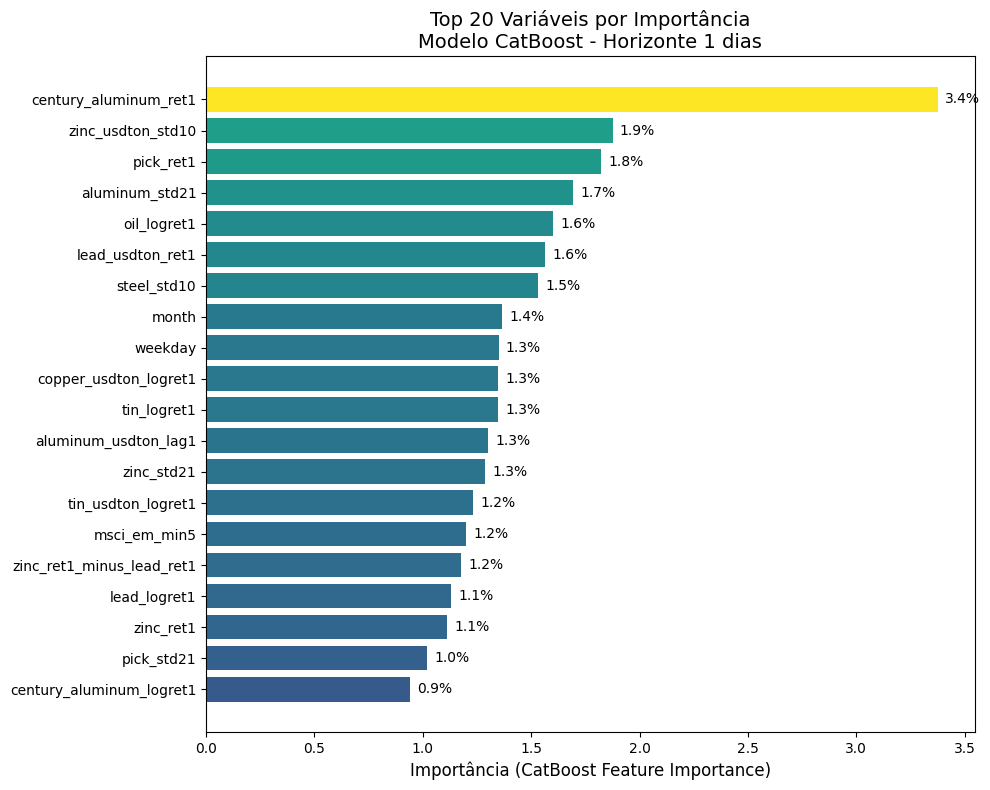

ANÁLISE DE IMPORTÂNCIA DAS FEATURES - HORIZONTE: 5 DIAS

Top 20 variáveis por importância do CatBoost:
                  feature  importance  percentual
0                   month   10.024262   10.024262
1               dxy_std21    6.170640    6.170640
2             tin_logret1    6.043131    6.043131
3             steel_std21    5.275941    5.275941
4               zinc_std5    5.163172    5.163172
5               gas_std10    5.030954    5.030954
6             alcoa_std10    4.244278    4.244278
7                 weekday    3.682786    3.682786
8              steel_ret1    3.623794    3.623794
9               fxi_max10    3.574598    3.574598
10          msci_em_max10    3.441860    3.441860
11          alcoa_logret1    3.420718    3.420718
12               fxi_max5    3.271154    3.271154
13   aluminum_usdton_lag1    3.038109    3.038109
14  copper_usdton_logret1    3.036737    3.036737
15               oil_min5    3.010983    3.010983
16         aluminum_lag21    2.839630    2.8396

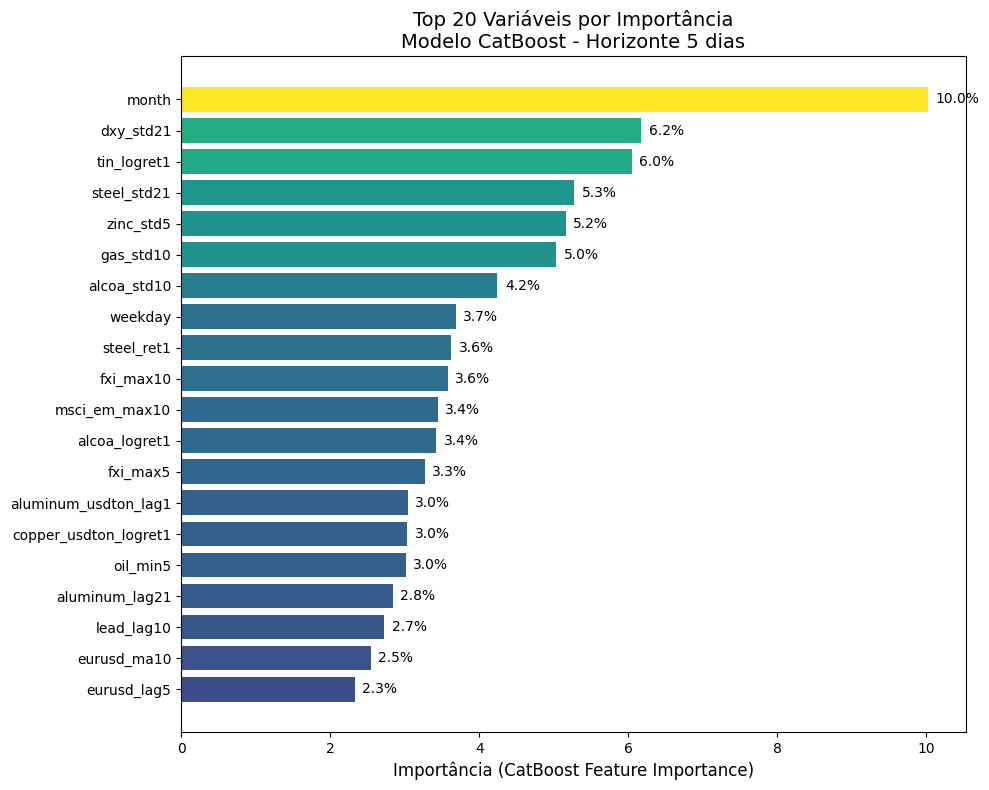

ANÁLISE DE IMPORTÂNCIA DAS FEATURES - HORIZONTE: 30 DIAS

Top 20 variáveis por importância do CatBoost:
                   feature  importance  percentual
0               steel_min5    5.646830    5.646830
1        zinc_usdton_max10    4.186630    4.186630
2                 tin_lag1    3.507637    3.507637
3         zinc_usdton_lag3    3.467990    3.467990
4            hindalco_max5    2.838431    2.838431
5                fxi_std21    2.824195    2.824195
6                 oil_lag3    2.709330    2.709330
7                 oil_min5    2.672941    2.672941
8     aluminum_usdton_lag1    2.546716    2.546716
9              tin_logret1    2.441731    2.441731
10           aluminum_lag1    2.382791    2.382791
11               zinc_ma21    2.382321    2.382321
12             alcoa_std10    2.370732    2.370732
13               xlb_min10    2.318158    2.318158
14  century_aluminum_min21    2.142324    2.142324
15            brlusd_std21    2.127805    2.127805
16              lead_lag10   

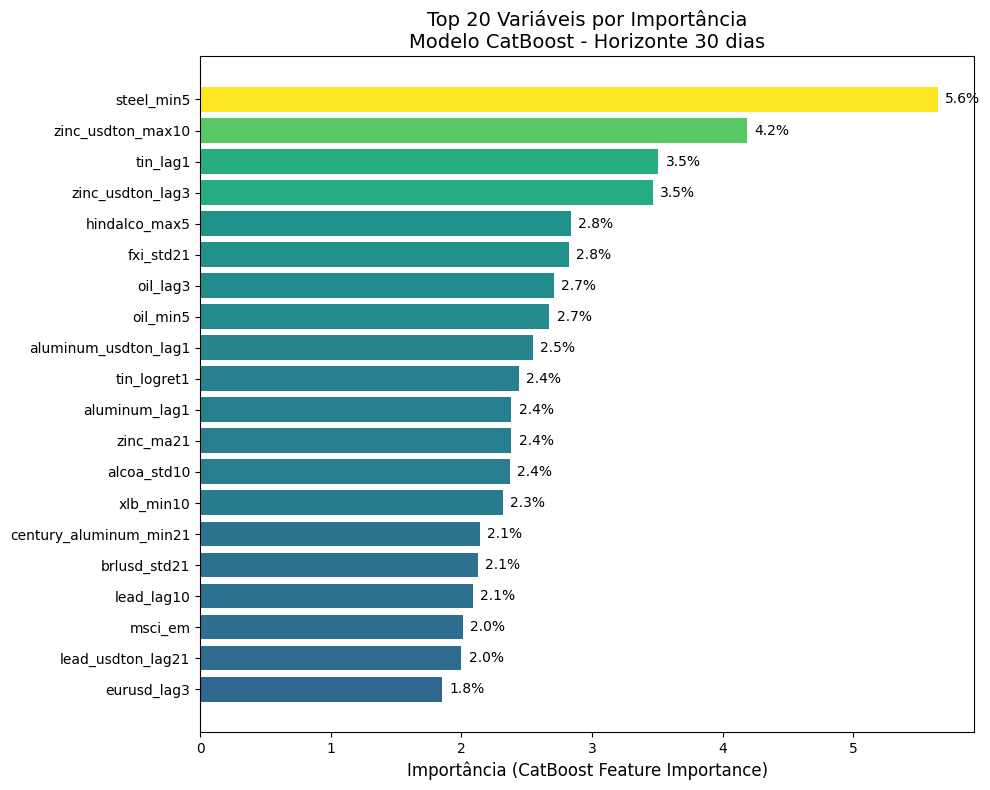

ANÁLISE DE IMPORTÂNCIA DAS FEATURES - HORIZONTE: 90 DIAS

Top 20 variáveis por importância do CatBoost:
                      feature  importance  percentual
0                  lead_std10    9.440313    9.440313
1            tin_usdton_max10    7.886871    7.886871
2                 steel_lag21    6.411619    6.411619
3                  steel_min5    6.348248    6.348248
4               hindalco_lag2    6.051060    6.051060
5        aluminum_usdton_lag1    5.995937    5.995937
6                   oil_lag10    5.390334    5.390334
7        aluminum_usdton_lag5    4.999881    4.999881
8                 tin_logret1    4.770785    4.770785
9                 steel_std10    4.076731    4.076731
10                  xlb_std21    3.422971    3.422971
11           zinc_usdton_ma10    3.151940    3.151940
12          zinc_usdton_lag10    2.803769    2.803769
13                      month    2.764266    2.764266
14                  pick_ret1    2.435267    2.435267
15                    quarter   

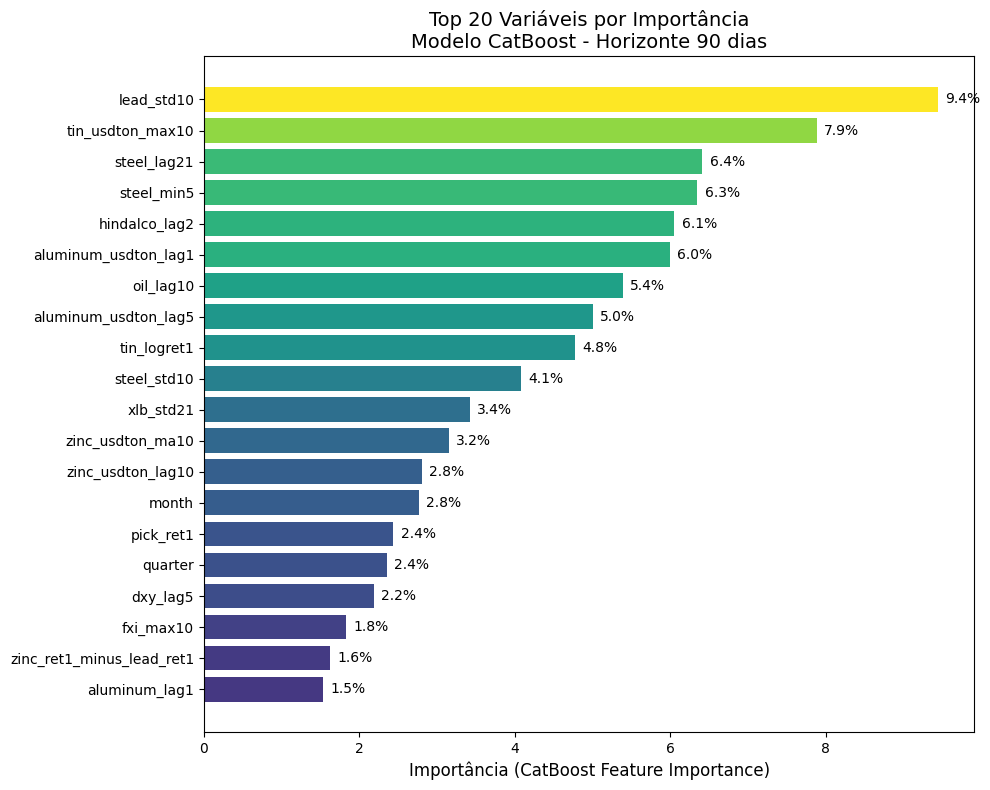



 Análise de importância de features concluída para todos os horizontes!


In [ ]:
# --- Célula de Análise de Importância de Features (Para Todos os Horizontes) ---

import joblib
import pandas as pd
import matplotlib.pyplot as plt

horizons_to_analyze = [1, 5, 30, 90]

for hz in horizons_to_analyze:
    print(f"=============================================================")
    print(f"ANÁLISE DE IMPORTÂNCIA DAS FEATURES - HORIZONTE: {hz} DIAS")
    print(f"=============================================================")

    try:
        model = joblib.load(f'catboost_model_horizon_{hz}d.joblib')
        test_df = joblib.load(f'test_df_horizon_{hz}d.joblib')

        feature_cols = [c for c in test_df.columns if c not in ['target', 'date', 'target_encoded']]

        importances = model.get_feature_importance()
        imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})

        imp_df['percentual'] = 100 * imp_df['importance'] / imp_df['importance'].sum()

        imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

        print("\nTop 20 variáveis por importância do CatBoost:")
        print(imp_df.head(20).to_string())

        csv_filename = f'catboost_importances_{hz}d.csv'
        imp_df.to_csv(csv_filename, index=False)
        print(f"\nArquivo com todas as importâncias salvo: {csv_filename}")

        TOP_N = 20
        plt.figure(figsize=(10, 8))
        
        plot_data = imp_df.head(TOP_N).sort_values('importance', ascending=True)
        
        bars = plt.barh(
            plot_data['feature'],
            plot_data['importance'],
            color=plt.cm.viridis(plot_data['percentual'] / plot_data['percentual'].max())
        )
        
        plt.xlabel("Importância (CatBoost Feature Importance)", fontsize=12)
        plt.title(f"Top {TOP_N} Variáveis por Importância\nModelo CatBoost - Horizonte {hz} dias", fontsize=14)
        
        for i, (pct, imp) in enumerate(zip(plot_data['percentual'], plot_data['importance'])):
            plt.text(imp + imp_df['importance'].max() * 0.01, i, f"{pct:.1f}%", va='center')
            
        plt.tight_layout()
        plt.show() 

    except FileNotFoundError:
        print(f"\nAVISO: Arquivos de modelo para o horizonte {hz}d não encontrados. Pulando esta etapa.")
        continue
    except Exception as e:
        print(f"\nOcorreu um erro inesperado ao processar o horizonte {hz}d: {e}")
        continue

print("\n\n Análise de importância de features concluída para todos os horizontes!")

In [1]:
# --- Célula de Comparação: CatBoost vs. Dummy Classifier (Most Frequent) ---

import pandas as pd
import joblib
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# Define os horizontes que queremos avaliar
horizons_to_evaluate = [1, 5, 30, 90]

# Lista para armazenar os resultados da comparação
comparison_summary = []

print("A comparar a performance dos modelos CatBoost com o Dummy Classifier...")

# Loop para carregar, treinar o dummy e comparar cada modelo
for hz in horizons_to_evaluate:
    try:
        # 1. Carrega os artefatos salvos
        model_catboost = joblib.load(f'catboost_model_horizon_{hz}d.joblib')
        train_df = joblib.load(f'train_df_horizon_{hz}d.joblib')
        test_df = joblib.load(f'test_df_horizon_{hz}d.joblib')
        label_encoder = joblib.load(f'label_encoder_horizon_{hz}d.joblib')
        
        # 2. Prepara os dados de treino e teste
        feature_cols = [c for c in test_df.columns if c not in ['target', 'date', 'target_encoded']]
        
        X_train = train_df[feature_cols]
        y_train = train_df['target_encoded']
        
        X_test = test_df[feature_cols]
        y_test = test_df['target_encoded']

        # --- Avaliação do Modelo CatBoost ---
        y_pred_catboost = model_catboost.predict(X_test)
        accuracy_catboost = accuracy_score(y_test, y_pred_catboost)
        f1_macro_catboost = f1_score(y_test, y_pred_catboost, average='macro', zero_division=0)

        # --- Treinamento e Avaliação do Dummy Classifier ---
        # A estratégia 'most_frequent' faz o modelo prever sempre a classe mais comum do y_train
        dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
        dummy_model.fit(X_train, y_train)
        y_pred_dummy = dummy_model.predict(X_test)
        
        accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
        f1_macro_dummy = f1_score(y_test, y_pred_dummy, average='macro', zero_division=0)

        # Armazena os resultados para a tabela final
        comparison_summary.append({
            'Horizonte (dias)': hz,
            'Modelo': 'CatBoost',
            'Acurácia': accuracy_catboost,
            'F1-Score (Macro)': f1_macro_catboost
        })
        comparison_summary.append({
            'Horizonte (dias)': hz,
            'Modelo': 'Dummy (Mais Frequente)',
            'Acurácia': accuracy_dummy,
            'F1-Score (Macro)': f1_macro_dummy
        })
        
        print(f"  - Horizonte {hz}d: Comparação concluída.")

    except FileNotFoundError:
        print(f"\nAVISO: Arquivos de modelo para o horizonte {hz}d não encontrados. A pular esta etapa.")
        continue
    except Exception as e:
        print(f"\nOcorreu um erro inesperado ao processar o horizonte {hz}d: {e}")
        continue

# --- Exibição dos Resultados Comparativos ---
if comparison_summary:
    # Converte a lista de resultados em um DataFrame do Pandas
    comparison_df = pd.DataFrame(comparison_summary)
    
    print("\n\n--- Tabela Comparativa de Performance: CatBoost vs. Dummy ---")
    
    # Exibe o DataFrame formatado para melhor visualização
    display(
        comparison_df.set_index(['Horizonte (dias)', 'Modelo']).style.format({
            'Acurácia': '{:.2%}',
            'F1-Score (Macro)': '{:.4f}'
        }).background_gradient(cmap='viridis', subset=['F1-Score (Macro)'])
    )
else:
    print("\nNenhum resultado para exibir. Verifique se os arquivos .joblib existem no diretório.")

A comparar a performance dos modelos CatBoost com o Dummy Classifier...
  - Horizonte 1d: Comparação concluída.
  - Horizonte 5d: Comparação concluída.
  - Horizonte 30d: Comparação concluída.
  - Horizonte 90d: Comparação concluída.


--- Tabela Comparativa de Performance: CatBoost vs. Dummy ---


A avaliar e a preparar os dados para os gráficos...
  - Horizonte 1d: Métricas calculadas.
  - Horizonte 5d: Métricas calculadas.
  - Horizonte 30d: Métricas calculadas.
  - Horizonte 90d: Métricas calculadas.

--- A gerar os gráficos de barras comparativos ---


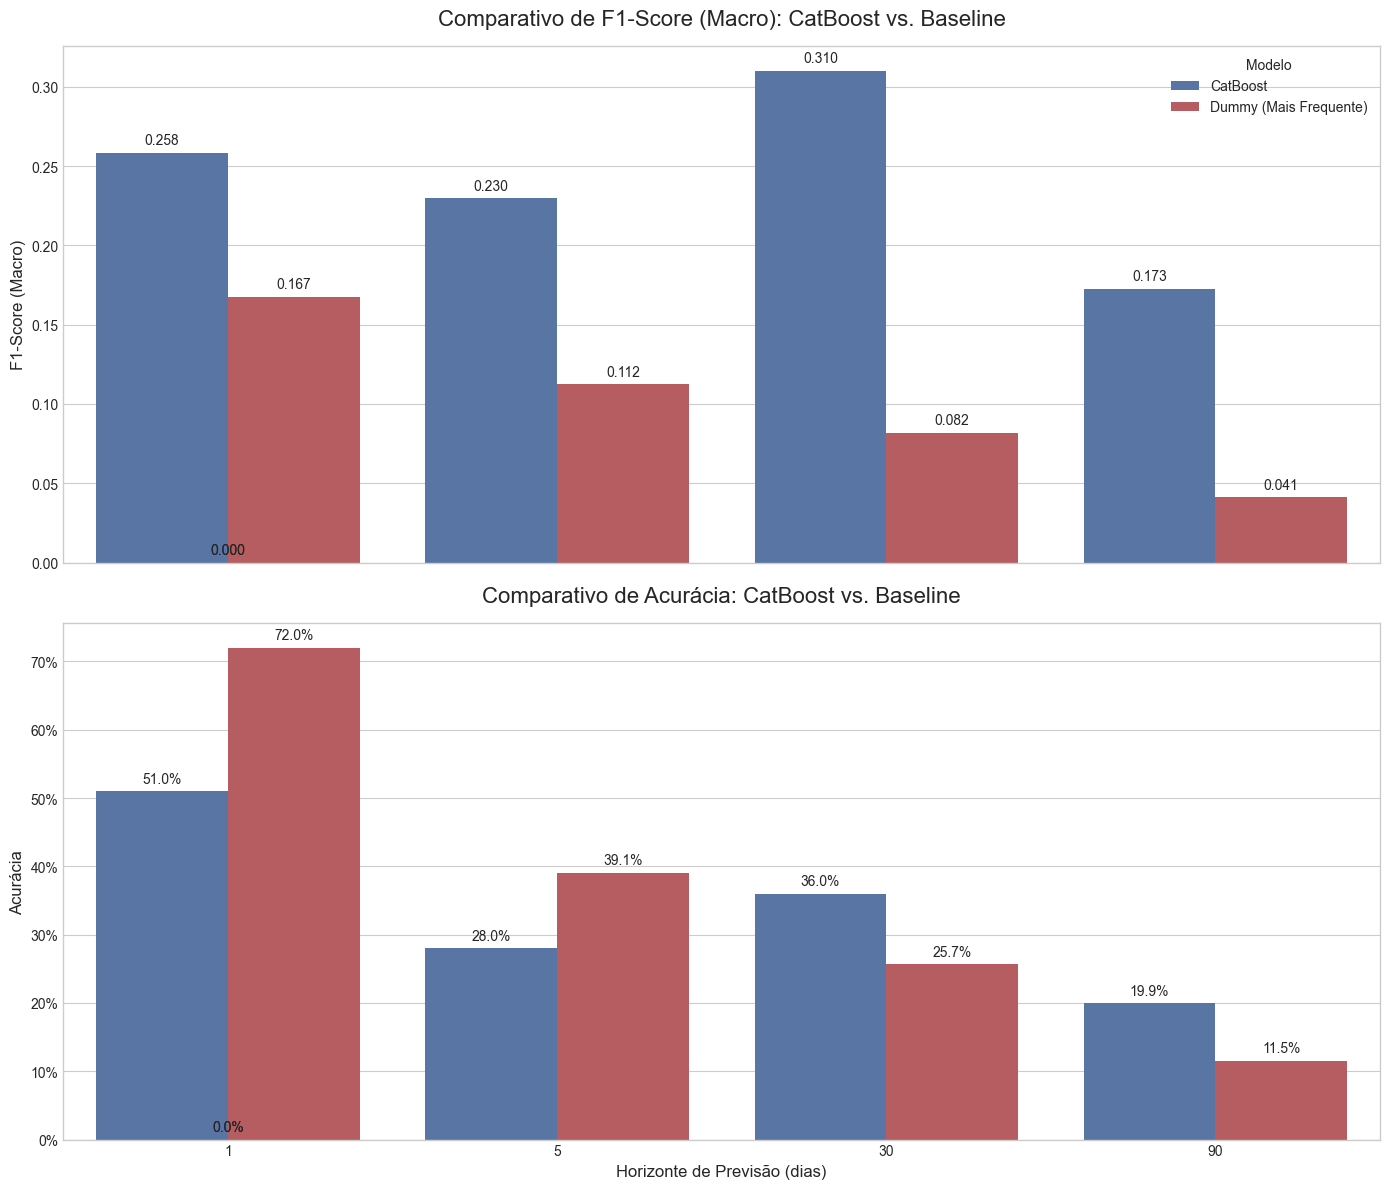

In [3]:
# --- Célula Final: Tabela e Gráficos Comparativos de Performance ---

import pandas as pd
import joblib
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Define os horizontes de interesse
horizons_to_evaluate = [1, 5, 30, 90]
comparison_summary = []

print("A avaliar e a preparar os dados para os gráficos...")

# Loop para calcular as métricas necessárias
for hz in horizons_to_evaluate:
    try:
        model_catboost = joblib.load(f'catboost_model_horizon_{hz}d.joblib')
        train_df = joblib.load(f'train_df_horizon_{hz}d.joblib')
        test_df = joblib.load(f'test_df_horizon_{hz}d.joblib')
        
        feature_cols = [c for c in test_df.columns if c not in ['target', 'date', 'target_encoded']]
        X_train, y_train = train_df[feature_cols], train_df['target_encoded']
        X_test, y_test = test_df[feature_cols], test_df['target_encoded']

        # Avaliação do CatBoost
        y_pred_catboost = model_catboost.predict(X_test)
        comparison_summary.append({
            'Horizonte (dias)': hz, 'Modelo': 'CatBoost',
            'Acurácia': accuracy_score(y_test, y_pred_catboost),
            'F1-Score (Macro)': f1_score(y_test, y_pred_catboost, average='macro', zero_division=0)
        })

        # Avaliação do Dummy
        dummy_model = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
        y_pred_dummy = dummy_model.predict(X_test)
        comparison_summary.append({
            'Horizonte (dias)': hz, 'Modelo': 'Dummy (Mais Frequente)',
            'Acurácia': accuracy_score(y_test, y_pred_dummy),
            'F1-Score (Macro)': f1_score(y_test, y_pred_dummy, average='macro', zero_division=0)
        })
        print(f"  - Horizonte {hz}d: Métricas calculadas.")

    except FileNotFoundError:
        print(f"\nAVISO: Arquivos para o horizonte {hz}d não encontrados.")

# --- Geração dos Gráficos de Barras ---
if comparison_summary:
    comparison_df = pd.DataFrame(comparison_summary)
    
    print("\n--- A gerar os gráficos de barras comparativos ---")
    
    plt.style.use('seaborn-v0_8-whitegrid')
    palette = {"CatBoost": "#4C72B0", "Dummy (Mais Frequente)": "#C44E52"}
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    
    # Gráfico 1: F1-Score (Macro)
    sns.barplot(data=comparison_df, x='Horizonte (dias)', y='F1-Score (Macro)', hue='Modelo', ax=ax1, palette=palette)
    ax1.set_title('Comparativo de F1-Score (Macro): CatBoost vs. Baseline', fontsize=16, pad=15)
    ax1.set_ylabel('F1-Score (Macro)', fontsize=12)
    ax1.set_xlabel('')
    ax1.legend(title='Modelo')
    for p in ax1.patches:
        ax1.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    # Gráfico 2: Acurácia
    sns.barplot(data=comparison_df, x='Horizonte (dias)', y='Acurácia', ax=ax2, hue='Modelo', palette=palette)
    ax2.set_title('Comparativo de Acurácia: CatBoost vs. Baseline', fontsize=16, pad=15)
    ax2.set_ylabel('Acurácia', fontsize=12)
    ax2.set_xlabel('Horizonte de Previsão (dias)', fontsize=12)
    ax2.get_legend().remove()
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    plt.tight_layout()
    plt.show()
else:
    print("\nNenhum dado para plotar. Certifique-se de que os arquivos .joblib existem.")